In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [11]:
circuit = QuantumCircuit(3, 3)
for qubit in range(3):
    circuit.h(qubit)
circuit.measure(range(3), range(3))





Expected Probability for each state = 1/8 = 0.125

Observed Probability Distribution:
000 : 0.115
001 : 0.137
010 : 0.117
011 : 0.126
100 : 0.121
101 : 0.136
110 : 0.116
111 : 0.132


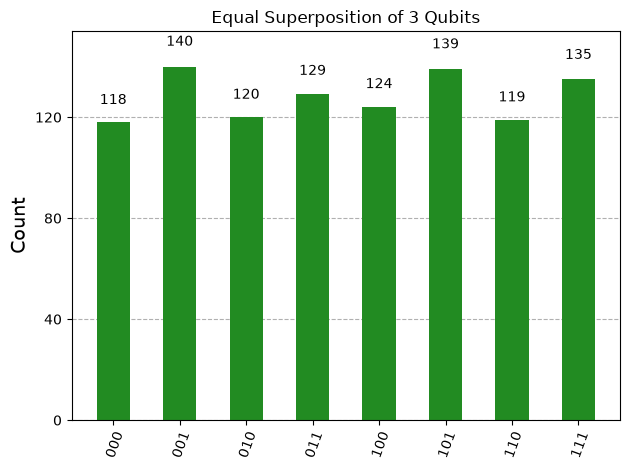

In [13]:
simulator = AerSimulator()

# Compile and execute the circuit
compiled = transpile(circuit, simulator)
job = simulator.run(compiled, shots=1024)

# Get measurement results
counts = job.result().get_counts()

# Calculate probabilities
print("Expected Probability for each state = 1/8 = 0.125\n")

print("Observed Probability Distribution:")
for state in sorted(counts.keys()):
    probability = counts[state] / 1024
    print(f"{state} : {probability:.3f}")

# Plot the histogram
plot_histogram(
    counts,
    color="forestgreen",
    title="Equal Superposition of 3 Qubits"
)